In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %pip install sncosmo
# %pip install sfdmap2
# %pip install lightcurvelynx

In [3]:
import matplotlib.pyplot as plt
import lsdb
import numpy as np
from lightcurvelynx.astro_utils.mag_flux import flux2mag
from astropy.cosmology import Planck18
from astropy.coordinates import Distance
import astropy.units as u
from joblib import Parallel, delayed
import pandas as pd
from nested_pandas import read_parquet
import sncosmo
from utils import nightly_coadd

from dask.distributed import Client

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
client = Client(n_workers=30, memory_limit="10 GiB", threads_per_worker=1)
display(client)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45589 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:45589/status,
Dashboard: http://127.0.0.1:45589/status,Workers: 30
Total threads: 30,Total memory: 300.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34681,Workers: 0
Dashboard: http://127.0.0.1:45589/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38921,Total threads: 1
Dashboard: http://127.0.0.1:41709/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:38791,


In [5]:
import os
os.environ["SFD_DIR"] = "/astro/users/midai/sfdmap2/sfddata-master"

In [6]:
DDF = True
refit_salt = True
SKIP_BAZIN = True

In [7]:
from pathlib import Path
outdir = Path('outputs/')

In [8]:
columns = ["max_reliability","max_snr","ndet","nbands","n_g","n_r","n_i","n_z","dt",
           "median_flux_diff_ratio","median_flux_diff_ratio_abs","_dist_arcsec"]
bins_map = {"median_flux_diff_ratio": np.linspace(0,5,20),
        "median_flux_diff_ratio_abs": np.linspace(0,1,20)}
if DDF:
    sncandid_filename = "sncandid_w_bazin_ddf"
else:
    sncandid_filename = "sncandid_w_bazin"
sncat_meta = lsdb.open_catalog(outdir / sncandid_filename,columns=columns)

In [9]:
len(sncat_meta)

2363

In [10]:
snmeta = sncat_meta.compute()

Computing Catalog: 100%|██████████| 386/386 [00:15<00:00, 25.30it/s] 


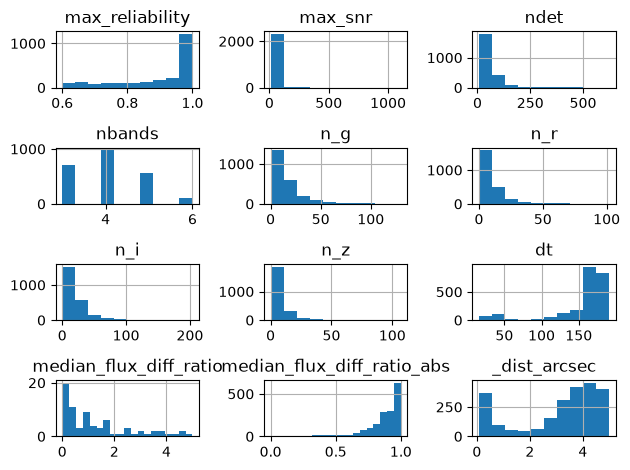

In [11]:
for i,col in enumerate(columns):
    plt.subplot(4,3,i+1)
    if col in bins_map.keys():
        bins = bins_map[col]
    else:
        bins = None
    snmeta[col].hist(bins=bins)
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
bazin_cols = [f"bazin_fit_reduced_chi2_{b}" for b in "griz"]
sncat_bazin = lsdb.open_catalog(outdir / sncandid_filename,columns=bazin_cols)

In [13]:
snbazin = sncat_bazin.compute()

Computing Catalog: 100%|██████████| 386/386 [00:01<00:00, 356.83it/s]


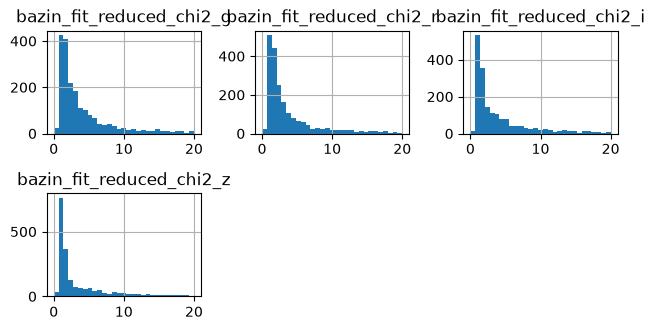

In [14]:
for i,col in enumerate(bazin_cols):
    plt.subplot(3,3,i+1)
    snbazin[col].hist(bins=np.linspace(0,20,30))
    plt.title(col)
plt.tight_layout()
plt.show()

In [15]:
sncat = lsdb.open_catalog(outdir / sncandid_filename)

In [16]:
def filter_bazin(df):
    df = df.query("((bazin_fit_reduced_chi2_r > 0.1 and bazin_fit_reduced_chi2_r < 10.0) or "
                  "(bazin_fit_reduced_chi2_g > 0.1 and bazin_fit_reduced_chi2_g < 10.0) or "
                  "(bazin_fit_reduced_chi2_i > 0.1 and bazin_fit_reduced_chi2_i < 10.0) or "
                  "(bazin_fit_reduced_chi2_z > 0.1 and bazin_fit_reduced_chi2_z < 10.0))")
    return df

In [17]:
if not SKIP_BAZIN:
    sn_good = sncat.map_partitions(filter_bazin)
else:
    sn_good = sncat

In [18]:
if DDF:
    goodsn_filename = "good_sne_ddf"
else:
    goodsn_filename = "good_sne"
print(goodsn_filename)

good_sne_ddf


In [19]:
sn_good.write_catalog(outdir / goodsn_filename,overwrite=True)

Writing Catalog: 100%|██████████| 386/386 [00:02<00:00, 148.69it/s]


In [20]:
sn_good = lsdb.open_catalog(outdir / goodsn_filename)

In [21]:
len(sn_good)

2363

In [22]:
head = sn_good.head()
head

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 29.57it/s]


diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1917249489901590914         786345496137435798        149.810325   
1917295856339863082         786338624189759988        148.471868   
1917336855912376826         788005346378519989        148.323705   
1917380927529543415         788005140220089091        148.878325   
1917621878768255901         786352849121444371        151.791744   

                     dec_dia_object_lc  refExtendedness_object_lc  \
_healpix_29                                                         
1917249489901590914           1.237134                        1.0   
1917295856339863082           1.197915                        1.0   
1917336855912376826           1.733376                        1.0   
1917380927529543415           1.890111                        1.0   
1917621878768255901           1.384517                        1.0   

                     refSizeExtendedness_object_lc  objectId_object_lc  \
_healpix_29                                                              
1917249489901590914                       0.887781  786345496137464836   
1917295856339863082                       0.955922  786338624189773250   
1917336855912376826                            1.0  788005346378536660   
1917380927529543415                            1.0  788005140220117148   
1917621878768255901                       0.883302  786352849121459109   

                     coord_ra_object_lc  coord_dec_object_lc  _dist_arcsec  \
_healpix_29                                                                  
1917249489901590914          149.810531             1.235932      4.389095   
1917295856339863082          148.471104             1.197026      4.218688   
1917336855912376826          148.323753             1.733293      0.345209   
1917380927529543415          148.878589             1.889092      3.790816   
1917621878768255901          151.791747             1.384477      0.145686   

                     ndet  ...  bazin_fit_reference_time_z  \
_healpix_29                ...                               
1917249489901590914    36  ...                  869.781555   
1917295856339863082     8  ...                  972.175903   
1917336855912376826    14  ...                  815.328003   
1917380927529543415    20  ...                  906.450073   
1917621878768255901     8  ...                  824.743347   

                     bazin_fit_rise_time_z  bazin_fit_fall_time_z  \
_healpix_29                                                         
1917249489901590914               8.574168             171.181503   
1917295856339863082              35.864429              73.279907   
1917336855912376826               3.449747               8.019769   
1917380927529543415                9.96982             146.929245   
1917621878768255901               0.380514                2.31111   

                     bazin_fit_reduced_chi2_z     chi2_g      chi2_r  \
_healpix_29                                                            
1917249489901590914                   0.88256  25.811449  139.555847   
1917295856339863082                  1.814879   16.59181   43.574722   
1917336855912376826                   1.00475   4.475433   26.895666   
1917380927529543415                  0.927823   6.673276    4.802541   
1917621878768255901                 79.656296  204.85379   77.414467   

                        chi2_i    chi2_z  \
_healpix_29                                
1917249489901590914  97.160583  0.859715   
1917295856339863082  18.260429  1.180543   
1917336855912376826  37.614197  0.959676   
1917380927529543415   3.348061  0.899699   
1917621878768255901  97.820404   77.9617   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1917249489901590914  [{midpointMjdTai: 60811.042085, band: 'i', psf...   
1917295856339863082  [{midpointMjdTai: 

In [23]:
colors = {"u": "pink",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc,saltpars=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    # plt.ylim(ylim)

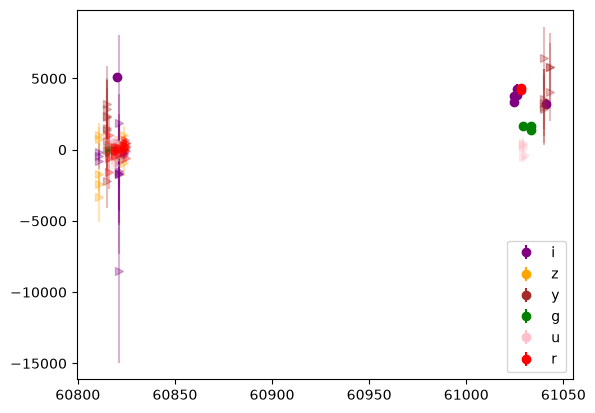

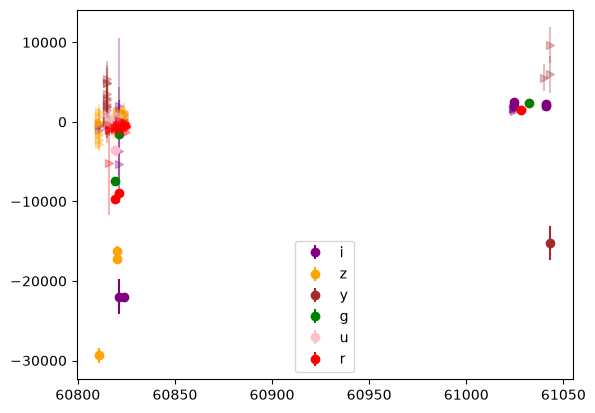

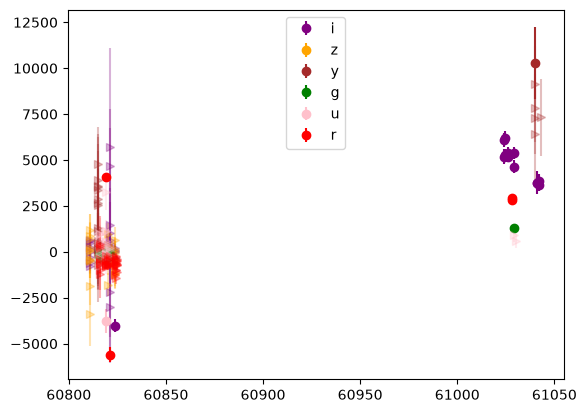

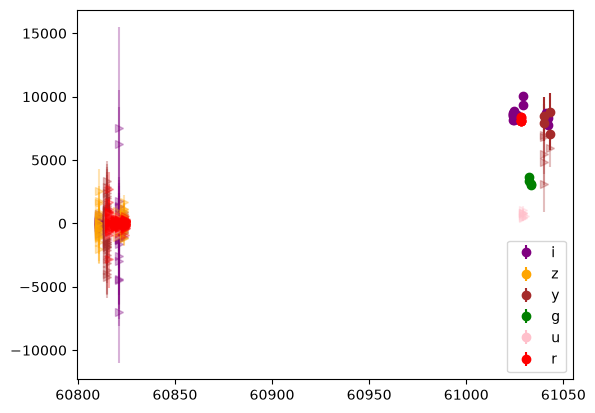

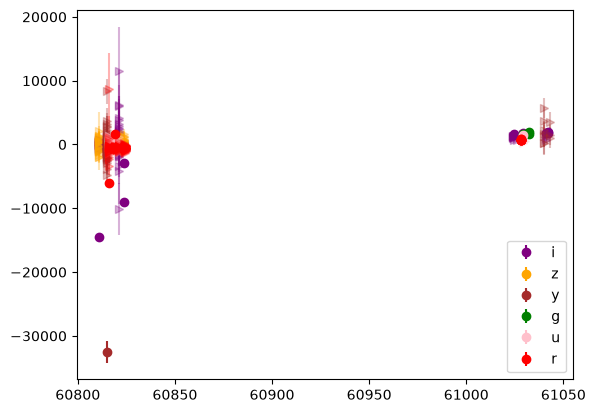

In [24]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [25]:
from lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.8),},
                         phase_range=(-15,45),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [26]:
def infer_z_from_peakmag(row):
    peakflux = np.max(row)
    peakmag = flux2mag(peakflux)
    z = Distance(distmod = peakmag + 19).compute_z(cosmology=Planck18).value
    return z

In [27]:
def compute_z_from_peakmag(df):
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=np.float32) for name in ["z_est"]}) 
    else:
        df = df.map_rows(infer_z_from_peakmag, columns=["diaSource_dia_object_lc.psfFlux"], row_container="args",
                         output_names=["z_est"], append_columns=True)
    return df

In [28]:
def fit_salt2(df):
    saltcolumns = ['success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err', 'x0',
           'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err', 'z_z_cov',
           'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
           't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
           't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
           'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
           'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
           'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
           'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
           'mwebv_mwebv_cov', 'id', 'fit_error']
    dtypes = [np.float64]*(len(saltcolumns)-2)+ [int] + [str]
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=dtype) for name,dtype in zip(saltcolumns,dtypes)}) 
    else:
        df = df.map_rows(fit_single_lc_w_cond, 
                         columns=["ra_dia_object_lc","dec_dia_object_lc","diaObjectId_dia_object_lc", "z_est",
                                  "diaSource_dia_object_lc.midpointMjdTai", "diaSource_dia_object_lc.band",
                                  "diaSource_dia_object_lc.psfFlux","diaSource_dia_object_lc.psfFluxErr"], 
                         append_columns=True)
    return df

In [29]:
sn_good = sn_good.map_partitions(compute_z_from_peakmag)

In [30]:
res = sn_good.map_partitions(fit_salt2,compute_single_partition=False)

In [31]:
head = res.head()

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
Computing Catalog: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]


In [32]:
head

diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1917249489901590914         786345496137435798        149.810325   
1917295856339863082         786338624189759988        148.471868   
1917336855912376826         788005346378519989        148.323705   
1917380927529543415         788005140220089091        148.878325   
1917621878768255901         786352849121444371        151.791744   

                     dec_dia_object_lc  refExtendedness_object_lc  \
_healpix_29                                                         
1917249489901590914           1.237134                        1.0   
1917295856339863082           1.197915                        1.0   
1917336855912376826           1.733376                        1.0   
1917380927529543415           1.890111                        1.0   
1917621878768255901           1.384517                        1.0   

                     refSizeExtendedness_object_lc  objectId_object_lc  \
_healpix_29                                                              
1917249489901590914                       0.887781  786345496137464836   
1917295856339863082                       0.955922  786338624189773250   
1917336855912376826                            1.0  788005346378536660   
1917380927529543415                            1.0  788005140220117148   
1917621878768255901                       0.883302  786352849121459109   

                     coord_ra_object_lc  coord_dec_object_lc  _dist_arcsec  \
_healpix_29                                                                  
1917249489901590914          149.810531             1.235932      4.389095   
1917295856339863082          148.471104             1.197026      4.218688   
1917336855912376826          148.323753             1.733293      0.345209   
1917380927529543415          148.878589             1.889092      3.790816   
1917621878768255901          151.791747             1.384477      0.145686   

                     ndet  ...   c_c_cov  c_mwebv_cov  mwebv_z_cov  \
_healpix_29                ...                                       
1917249489901590914    36  ...  0.000350          0.0          0.0   
1917295856339863082     8  ...  0.005162          0.0          0.0   
1917336855912376826    14  ...  0.012198          0.0          0.0   
1917380927529543415    20  ...  0.002569          0.0          0.0   
1917621878768255901     8  ...  0.003646          0.0          0.0   

                     mwebv_t0_cov  mwebv_x0_cov  mwebv_x1_cov  mwebv_c_cov  \
_healpix_29                                                                  
1917249489901590914           0.0           0.0           0.0          0.0   
1917295856339863082           0.0           0.0           0.0          0.0   
1917336855912376826           0.0           0.0           0.0          0.0   
1917380927529543415           0.0           0.0           0.0          0.0   
1917621878768255901           0.0           0.0           0.0          0.0   

                     mwebv_mwebv_cov                  id  fit_error  
_healpix_29                                                          
1917249489901590914              0.0  786345496137435798       None  
1917295856339863082              0.0  786338624189759988       None  
1917336855912376826              0.0  788005346378519989       None  
1917380927529543415              0.0  788005140220089091       None  
1917621878768255901              0.0  786352849121444371       None  

[5 rows x 105 columns]

In [88]:
if DDF:
    res_filename = "saltfit_good_sne_ddf.parquet"
else:
    res_filename = "saltfit_good_sne.parquet"

In [34]:
sn_to_fit = sn_good

In [89]:
if refit_salt:
    results = res.compute()
    results.to_parquet(outdir / res_filename)
else:
    results = read_parquet(outdir / res_filename)

In [90]:
results

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
0            786345496137435798        149.810325           1.237134   
1            786338624189759988        148.471868           1.197915   
...                         ...               ...                ...   
2361         756862229277573147         52.601561         -26.329552   
2362         756862229277573227         52.448761          -26.27671   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
0                           1.0                       0.887781   
1                           1.0                       0.955922   
...                         ...                            ...   
2361                        1.0                       0.985721   
2362                        1.0                       0.999641   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  \
0     786345496137464836          149.810531             1.235932   
1     786338624189773250          148.471104             1.197026   
...                  ...                 ...                  ...   
2361  756862229277594366           52.601237           -26.330639   
2362  756862229277595915           52.448058           -26.276378   

      _dist_arcsec  ndet  ...  c_mwebv_cov  mwebv_z_cov  mwebv_t0_cov  \
0         4.389095    36  ...          0.0          0.0           0.0   
1         4.218688     8  ...          0.0          0.0           0.0   
...            ...   ...  ...          ...          ...           ...   
2361      4.052577    33  ...          0.0          0.0           0.0   
2362      2.563263    21  ...          0.0          0.0           0.0   

      mwebv_x0_cov  mwebv_x1_cov  mwebv_c_cov  mwebv_mwebv_cov  \
0              0.0           0.0          0.0              0.0   
1              0.0           0.0          0.0              0.0   
...            ...           ...          ...              ...   
2361           0.0           0.0          0.0              0.0   
2362           0.0           0.0          0.0              0.0   

                      id  fit_error          _healpix_29  
0     786345496137435798       None  1917249489901590914  
1     786338624189759988       None  1917295856339863082  
...                  ...        ...                  ...  
2361  756862229277573147       None  2542432065760377088  
2362  756862229277573227       None  2542434392270677400  

[2363 rows x 106 columns]

In [91]:
result_good = results.loc[results.success == 1]

In [92]:
result_good

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
0            786345496137435798        149.810325           1.237134   
1            786338624189759988        148.471868           1.197915   
...                         ...               ...                ...   
2361         756862229277573147         52.601561         -26.329552   
2362         756862229277573227         52.448761          -26.27671   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
0                           1.0                       0.887781   
1                           1.0                       0.955922   
...                         ...                            ...   
2361                        1.0                       0.985721   
2362                        1.0                       0.999641   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  \
0     786345496137464836          149.810531             1.235932   
1     786338624189773250          148.471104             1.197026   
...                  ...                 ...                  ...   
2361  756862229277594366           52.601237           -26.330639   
2362  756862229277595915           52.448058           -26.276378   

      _dist_arcsec  ndet  ...  c_mwebv_cov  mwebv_z_cov  mwebv_t0_cov  \
0         4.389095    36  ...          0.0          0.0           0.0   
1         4.218688     8  ...          0.0          0.0           0.0   
...            ...   ...  ...          ...          ...           ...   
2361      4.052577    33  ...          0.0          0.0           0.0   
2362      2.563263    21  ...          0.0          0.0           0.0   

      mwebv_x0_cov  mwebv_x1_cov  mwebv_c_cov  mwebv_mwebv_cov  \
0              0.0           0.0          0.0              0.0   
1              0.0           0.0          0.0              0.0   
...            ...           ...          ...              ...   
2361           0.0           0.0          0.0              0.0   
2362           0.0           0.0          0.0              0.0   

                      id  fit_error          _healpix_29  
0     786345496137435798       None  1917249489901590914  
1     786338624189759988       None  1917295856339863082  
...                  ...        ...                  ...  
2361  756862229277573147       None  2542432065760377088  
2362  756862229277573227       None  2542434392270677400  

[2280 rows x 106 columns]

In [93]:
result_good = result_good.loc[(result_good.x1 > -3.99) & (result_good.x1 < 3.99) & (result_good.c > -0.399) & (result_good.c < 0.799)]

<Axes: >

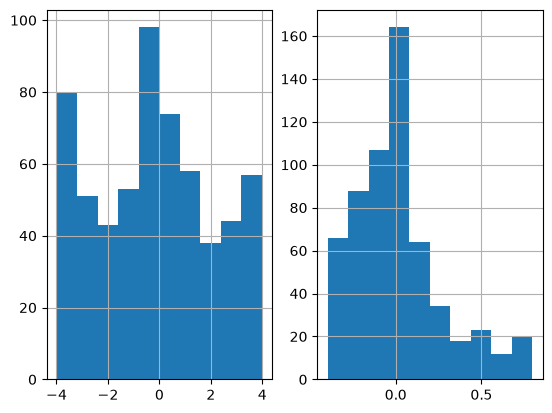

In [94]:
plt.subplot(1,2,1)
result_good.x1.hist()
plt.subplot(1,2,2)
result_good.c.hist()

In [95]:
result_good["reduced_chisq"] = result_good.chisq / result_good.ndof

<Axes: >

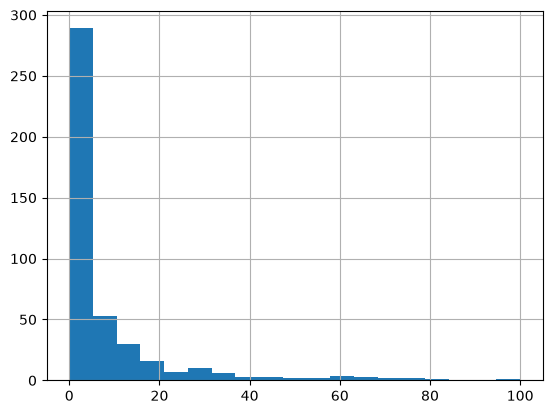

In [96]:
result_good.reduced_chisq.hist(bins = np.linspace(0, 100, 20))

In [97]:
result_good = result_good.loc[(result_good.reduced_chisq > 0.) & (result_good.reduced_chisq < 20.)]

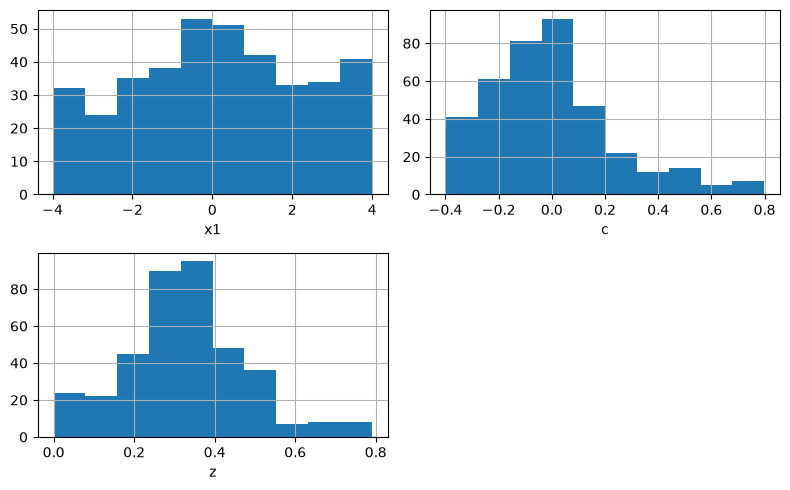

In [98]:
fig = plt.figure(figsize=(8,5))
plt.subplot(2,2,1)
result_good.x1.hist()
plt.xlabel('x1')
plt.subplot(2,2,2)
result_good.c.hist()
plt.xlabel('c')
plt.subplot(2,2,3)
result_good.z.hist()
plt.xlabel('z')
plt.tight_layout()

In [99]:
sn_good = result_good

In [100]:
sn_good

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
1            786338624189759988        148.471868           1.197915   
2            788005346378519989        148.323705           1.733376   
...                         ...               ...                ...   
2360         756862779033387010         52.879226          -26.17349   
2362         756862229277573227         52.448761          -26.27671   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
1                           1.0                       0.955922   
2                           1.0                            1.0   
...                         ...                            ...   
2360                        1.0                            1.0   
2362                        1.0                       0.999641   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  \
1     786338624189773250          148.471104             1.197026   
2     788005346378536660          148.323753             1.733293   
...                  ...                 ...                  ...   
2360  756862779033404867           52.879601           -26.172483   
2362  756862229277595915           52.448058           -26.276378   

      _dist_arcsec  ndet  ...  mwebv_z_cov  mwebv_t0_cov  mwebv_x0_cov  \
1         4.218688     8  ...          0.0           0.0           0.0   
2         0.345209    14  ...          0.0           0.0           0.0   
...            ...   ...  ...          ...           ...           ...   
2360      3.825473    10  ...          0.0           0.0           0.0   
2362      2.563263    21  ...          0.0           0.0           0.0   

      mwebv_x1_cov  mwebv_c_cov  mwebv_mwebv_cov                  id  \
1              0.0          0.0              0.0  786338624189759988   
2              0.0          0.0              0.0  788005346378519989   
...            ...          ...              ...                 ...   
2360           0.0          0.0              0.0  756862779033387010   
2362           0.0          0.0              0.0  756862229277573227   

      fit_error          _healpix_29  reduced_chisq  
1          None  1917295856339863082       1.062302  
2          None  1917336855912376826       1.773421  
...         ...                  ...            ...  
2360       None  2542431203816326832       1.388475  
2362       None  2542434392270677400       3.744976  

[383 rows x 107 columns]

In [101]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[(phases >=-10) & (phases <=40)])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [102]:
sn = sn_good
# sn = sn_good[sn_good["dt"] >180]
sn["diaObjectForcedSource_dia_object_lc.snr"] = sn["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/sn["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
sn_det = sn.query("diaObjectForcedSource_dia_object_lc.snr > 5")
pass_quality_cut = sn_det.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                               "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                               "diaObjectForcedSource_dia_object_lc.band","z","t0"],
                               row_container="args")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
sn["pass_quality_cuts"] = False
sn.loc[idx,"pass_quality_cuts"] = True
sn = sn[sn["pass_quality_cuts"] == True]

In [103]:
len(sn)

145

169.9279237783776
{'x0': 1.1683210489265449e-05, 'x1': -0.9024407777365935, 'c': -0.03439825484657478, 'z': 0.4686595167467108, 'mwebv': 0.007175067736845359, 't0': 61005.57809703174}
dist,reduced_chi2= 0.5765919791611099 1.679648790098032


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


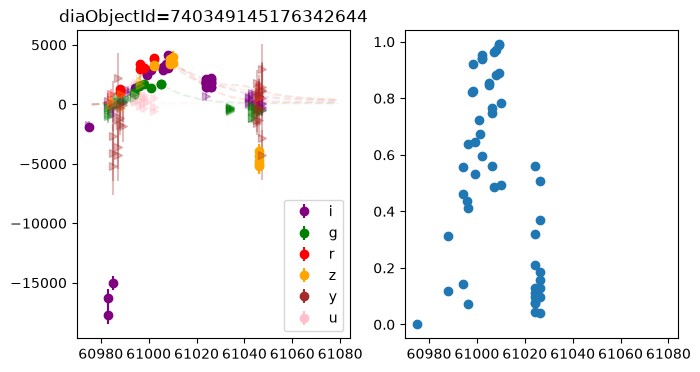

145.82552958486485
{'x0': 1.9171362193334904e-05, 'x1': -2.1423394642719513, 'c': -0.09155790278119662, 'z': 0.3364114361240103, 'mwebv': 0.00428431199007535, 't0': 60998.26650686548}
dist,reduced_chi2= 0.36091151943751737 9.876183393846144


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


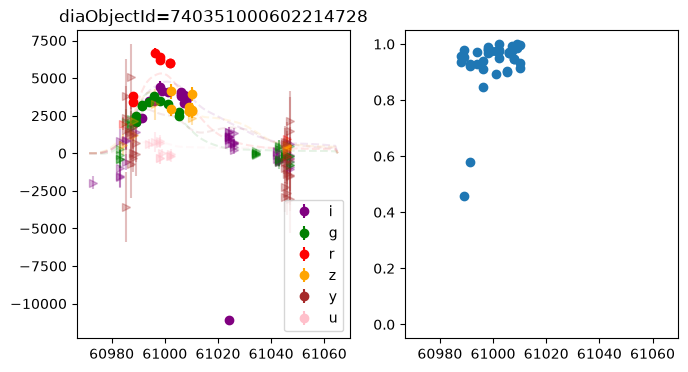

149.93061909260723
{'x0': 1.8568498953240106e-05, 'x1': 3.8243098247383753, 'c': -0.003238508235747631, 'z': 0.30020110856318993, 'mwebv': 0.011203373537535869, 't0': 60885.93315461056}
dist,reduced_chi2= 4.001147780116169 3.929683190854561


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


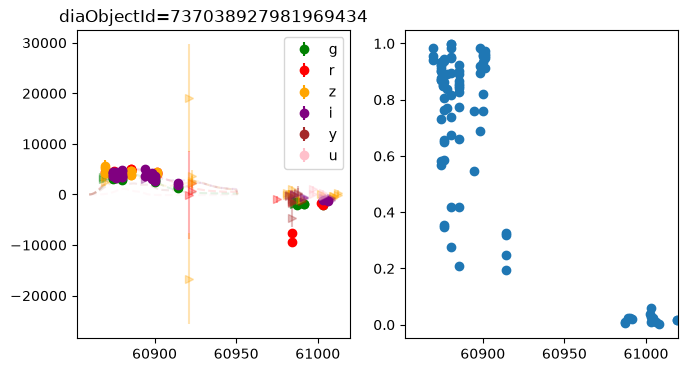

189.86086736109428
{'x0': 1.0504239795183787e-05, 'x1': -2.7470093731680167, 'c': -0.1701636355023771, 'z': 0.5342363259898936, 'mwebv': 0.00710903466530621, 't0': 60916.4714761578}
dist,reduced_chi2= 2.8800292576239723 6.606252135623276


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


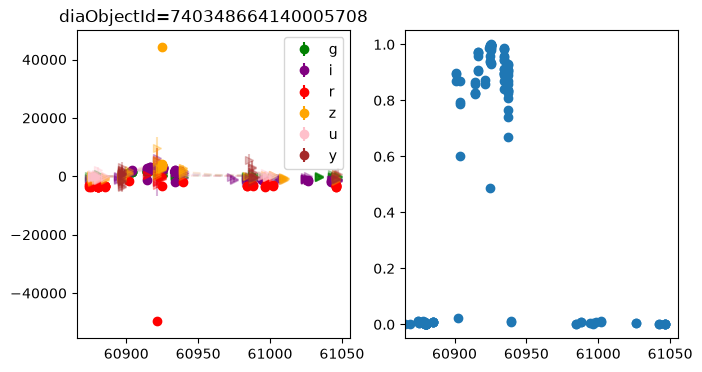

168.9650235434092
{'x0': 2.9492761475147445e-05, 'x1': -0.9016461010911173, 'c': 0.13752817445112744, 'z': 0.2154826253865387, 'mwebv': 0.0077276191968526035, 't0': 61037.301793181716}
dist,reduced_chi2= 1.0645711102509567 1.1233640555158033


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


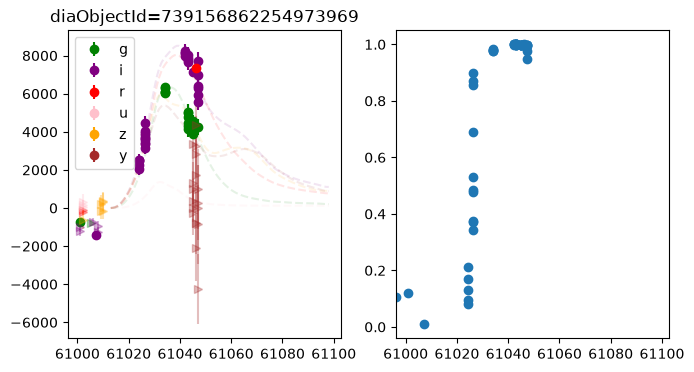

17.96627238086512
{'x0': 1.3071511767707011e-05, 'x1': 1.066993814830548, 'c': 0.06763602985059484, 'z': 0.1837614104165839, 'mwebv': 0.03246503314120898, 't0': 61037.21036776166}
dist,reduced_chi2= 4.748639660942215 7.649163157400426


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


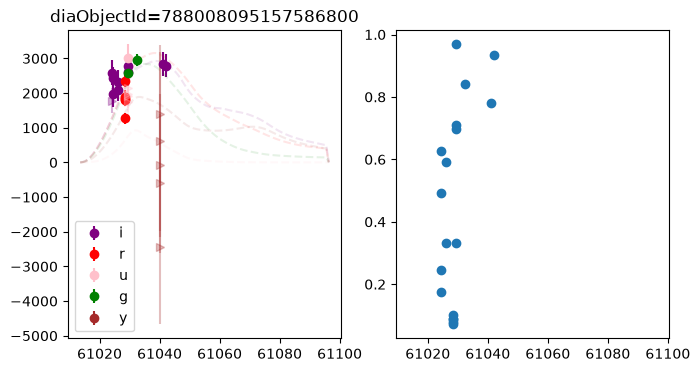

25.924413513865147
{'x0': 7.076452436572835e-06, 'x1': 0.5389193117672186, 'c': 0.19177386387116957, 'z': 0.31841856988004297, 'mwebv': 0.0112666950412214, 't0': 60885.376422171066}
dist,reduced_chi2= 0.16686278564400678 1.4787616500757048


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


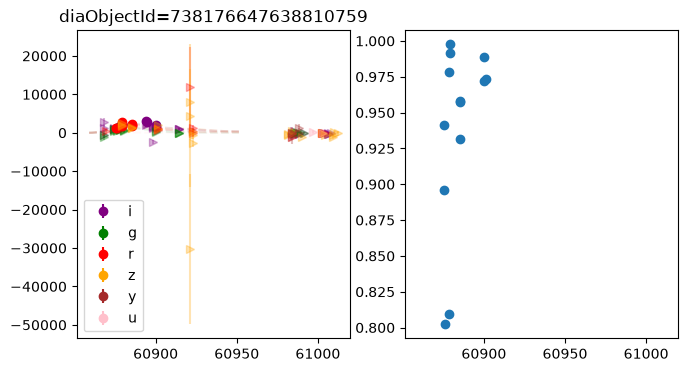

45.95091956878605
{'x0': 1.378321293953979e-05, 'x1': 3.435442815278097, 'c': -0.036886742690565834, 'z': 0.23661019278529094, 'mwebv': 0.009330228778034326, 't0': 60869.55108679297}
dist,reduced_chi2= 0.656518655221466 1.0909037906088015


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


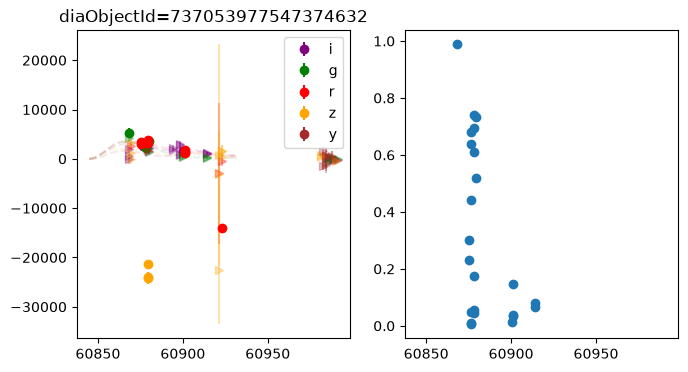

22.019506020689732
{'x0': 3.687587868324113e-05, 'x1': 1.072672824342932, 'c': -0.07066008284844284, 'z': 0.30292127891353565, 'mwebv': 0.010517903206900527, 't0': 61037.84042400643}
dist,reduced_chi2= 4.102624766198863 6.921090659477047


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


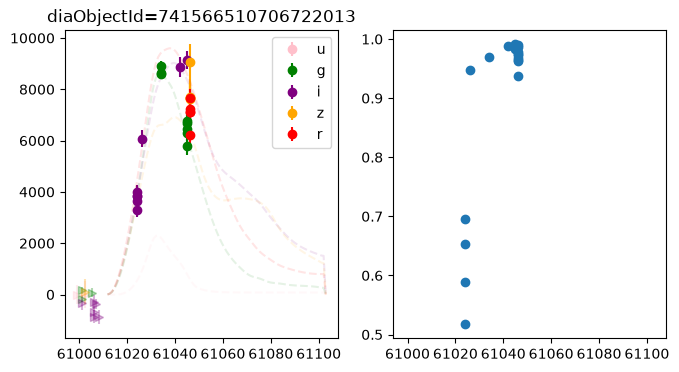

185.89545259813895
{'x0': 1.310812495406303e-05, 'x1': -2.645319947471565, 'c': -0.351360786695668, 'z': 0.7450842102008134, 'mwebv': 0.007978806762317074, 't0': 61000.38578012371}
dist,reduced_chi2= 3.6735245930356344 7.6268211157712615


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


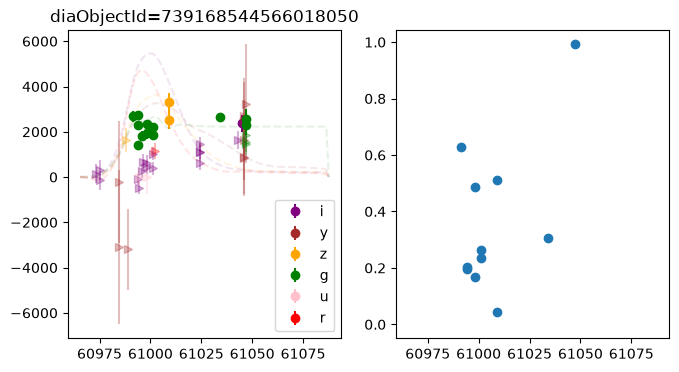

148.78897868728382
{'x0': 2.2245767827139107e-05, 'x1': 0.21614802923452456, 'c': -0.06255676239336422, 'z': 0.20040102246220948, 'mwebv': 0.009220021460542821, 't0': 60884.980009122046}
dist,reduced_chi2= 0.9584336634644277 2.916982265758404


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


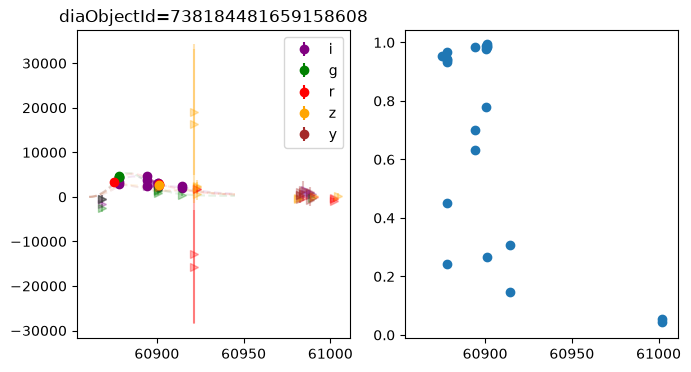

35.977582433137286
{'x0': 7.739530927634683e-06, 'x1': 1.3064100725069245, 'c': 0.4253721629777308, 'z': 0.25652907619628407, 'mwebv': 0.015412753147898781, 't0': 60888.252594218044}
dist,reduced_chi2= 0.20577303676644526 1.218568694516036


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


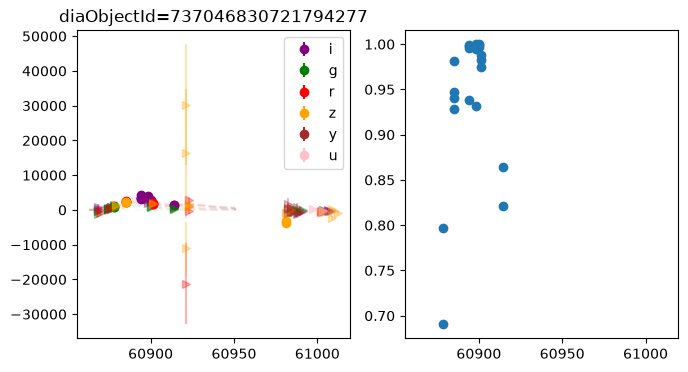

170.79151653667213
{'x0': 1.3729795092384701e-05, 'x1': -3.7617084840155193, 'c': 0.11502093382417158, 'z': 2.4684019820218203e-11, 'mwebv': 0.010048758432155669, 't0': 61021.49736763411}
dist,reduced_chi2= 0.09471808200660846 15.178339321642204


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


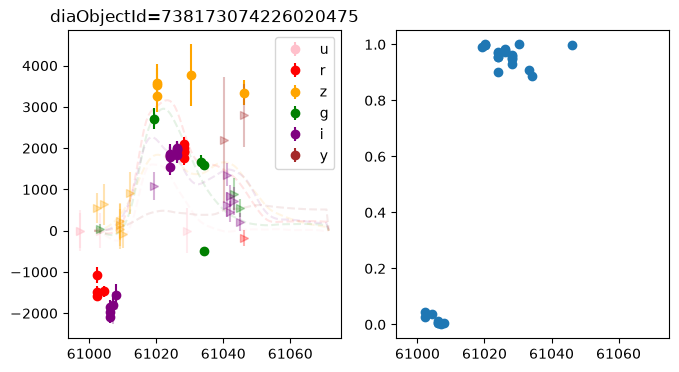

190.8739654605597
{'x0': 1.852880878084199e-05, 'x1': 3.7537015539791705, 'c': 0.13265082771920364, 'z': 0.1412800219238113, 'mwebv': 0.008017652752563269, 't0': 61040.105982641806}
dist,reduced_chi2= 4.930649734818936 5.052831265860063


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


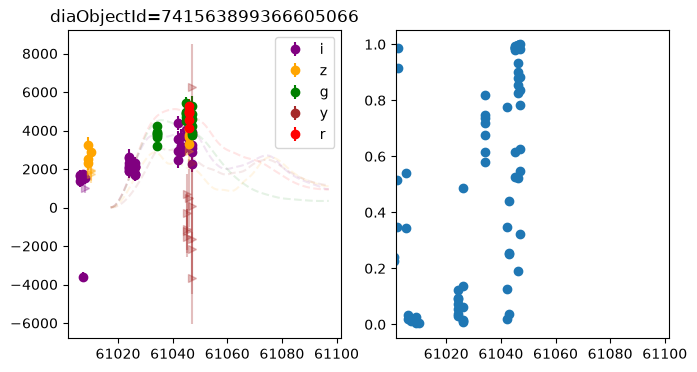

189.86130260083883
{'x0': 9.014666437333952e-06, 'x1': -1.6778336252190995, 'c': 0.4274155034993729, 'z': 0.24913737694026403, 'mwebv': 0.006337183134867268, 't0': 60899.91884589025}
dist,reduced_chi2= 0.4513800596366828 8.026693124798836


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


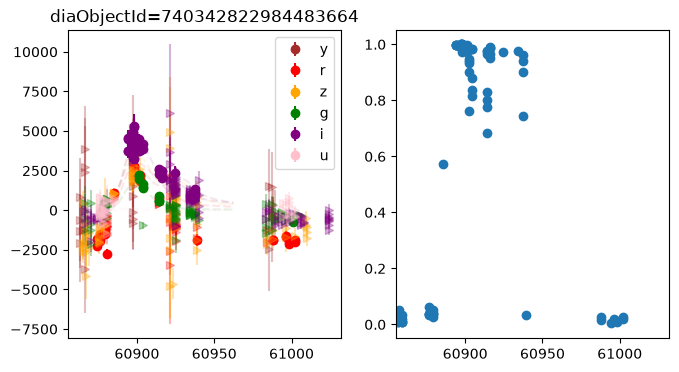

171.83372037217487
{'x0': 6.592504788443566e-06, 'x1': 2.3360748864218692, 'c': -0.11655869356040405, 'z': 0.5233837710135003, 'mwebv': 0.014660218394986496, 't0': 61039.45757183827}
dist,reduced_chi2= 3.4696145710077797 3.868169995357247


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


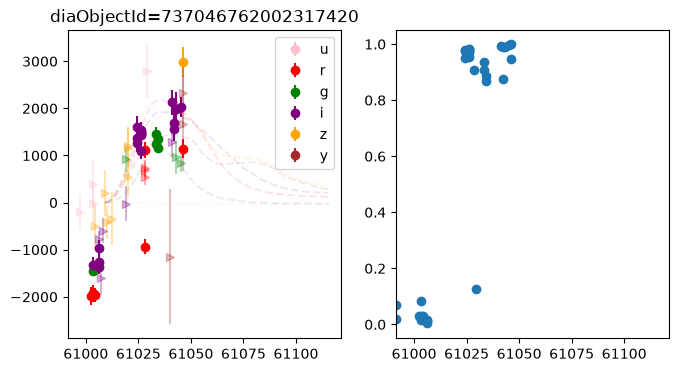

39.96437428050558
{'x0': 9.31533417342957e-06, 'x1': 3.3720252976725646, 'c': -0.12311638663834222, 'z': 0.21040581947175127, 'mwebv': 0.005821578318745112, 't0': 60883.26302771016}
dist,reduced_chi2= 0.14497986052760703 1.631260786961148


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


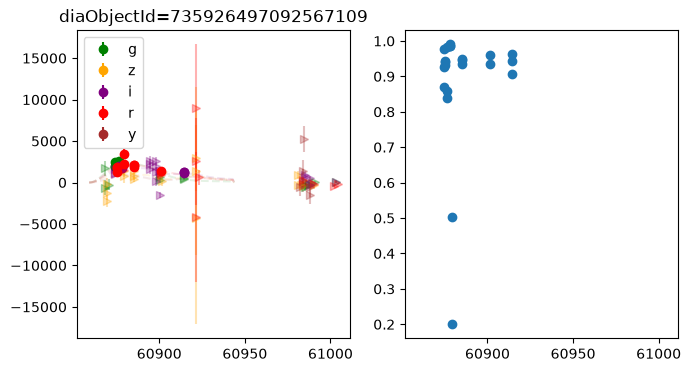

177.87924506015406
{'x0': 9.324167187472487e-06, 'x1': 2.613936551988555, 'c': 0.028010611341291035, 'z': 0.22799057520561822, 'mwebv': 0.006137165075143143, 't0': 60865.66683268808}
dist,reduced_chi2= 4.505846228982461 1.0987599299307633


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


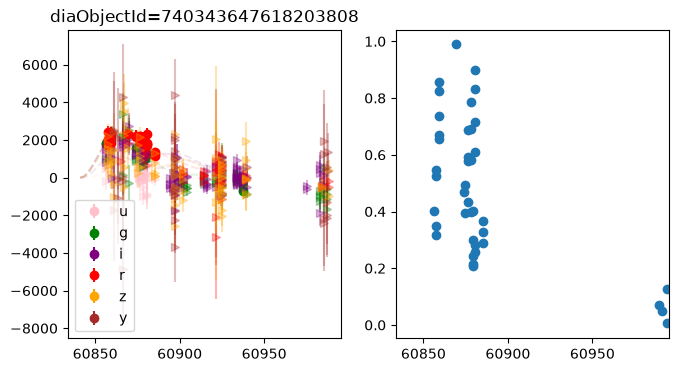

132.85378792945994
{'x0': 1.4428269600369681e-05, 'x1': 0.14564638639830527, 'c': 0.06824032401155113, 'z': 0.31767459958135885, 'mwebv': 0.005697290626319401, 't0': 61037.82293725873}
dist,reduced_chi2= 0.2684227128486984 2.131116060058835


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


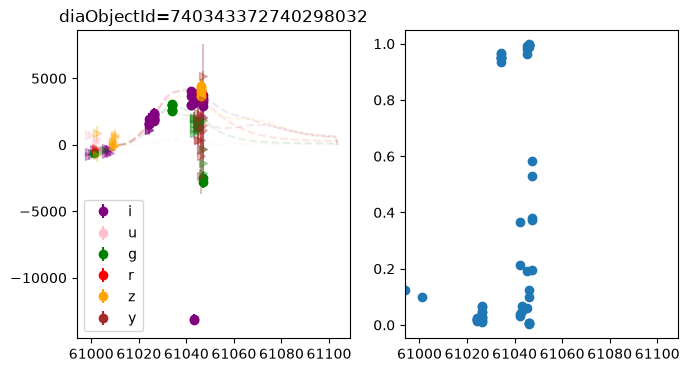

44.95293797875638
{'x0': 2.3304264926941867e-05, 'x1': -0.756872294808014, 'c': 0.05496677794120026, 'z': 0.3062722318609941, 'mwebv': 0.011458125387886417, 't0': 60868.83621109695}
dist,reduced_chi2= 0.4380299941917759 1.7006688368203893


/local/tmp/ipykernel_2705127/3219608627.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


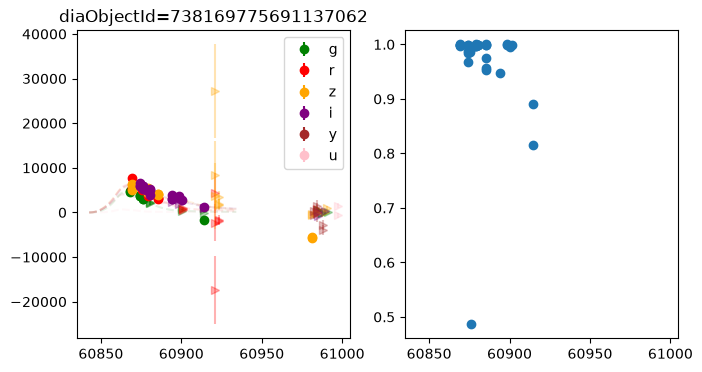

In [104]:
from legacy_survey_cutout import plot_legacy_cutout
cols = ["x0","x1","c","z","mwebv","t0"]
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    print(sn.iloc[i]["dt"])
    saltpars_df = result_good.loc[result_good.id==sn.iloc[i]["diaObjectId_dia_object_lc"]]
    saltpars = {}
    for col in cols:
        saltpars[col] = saltpars_df[col].values[0]
    print(saltpars)
    print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))
    plt.figure(figsize=(12,4))
    ax = plt.subplot(1,3,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    phase = (lc["midpointMjdTai"] - saltpars["t0"])/(1.+saltpars["z"])
    good_phase = (phase > -30) & (phase < 100)
    lc = lc.loc[good_phase]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    # lc_coadd = nightly_coadd(lc["mjd"],lc["band"],lc["flux"],lc["fluxerr"])
    # lc_coadd["snr"] = lc_coadd["flux"]/lc_coadd["fluxerr"]
    # plot_lc(lc_coadd,saltpars=saltpars)
    plot_lc(lc,saltpars=saltpars)
    plt.title(f"diaObjectId={sn.iloc[i]['diaObjectId_dia_object_lc']}")
    # plt.subplot(1,3,1)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc,saltpars=saltpars)
    ax2 = plt.subplot(1,3,2)
    plt.plot(sn.iloc[i]["diaSource_dia_object_lc"]["midpointMjdTai"],sn.iloc[i]["diaSource_dia_object_lc"]["reliability"],'o')
    plt.xlim(ax.get_xlim())
    # ax = plt.subplot(1,3,3)
    # ra = sn.iloc[i]["ra_dia_object_lc"]
    # dec = sn.iloc[i]["dec_dia_object_lc"]
    # img = plot_legacy_cutout(ra, dec, size=115, pixscale=0.262, layer="ls-dr10", fmt="jpg",ax=ax)
    plt.show()

In [105]:
sn.to_parquet(outdir / "final_sample_ddf.parquet")